In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks

# 1. Enable Mixed Precision for faster training on T4 GPU
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# 2. Data Loading & Augmentation
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.1),
])

# 3. Pre-Activation Residual Block (The CS231n special)
def res_block(x, filters, stride=1):
    shortcut = x

    # Pre-activation: BN -> ReLU -> Conv
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # First Conv
    x = layers.Conv2D(filters, (3, 3), strides=stride, padding='same', use_bias=False,
                      kernel_regularizer=regularizers.l2(1e-4))(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Second Conv
    x = layers.Conv2D(filters, (3, 3), strides=1, padding='same', use_bias=False,
                      kernel_regularizer=regularizers.l2(1e-4))(x)

    # Adjust shortcut if dimensions changed
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=stride, padding='same', use_bias=False)(shortcut)

    return layers.Add()([x, shortcut])

# 4. Building the Model
def build_resnet_cifar():
    inputs = layers.Input(shape=(32, 32, 3))
    x = data_augmentation(inputs)

    # Initial Stem
    x = layers.Conv2D(64, (3, 3), padding='same', use_bias=False)(x)

    # ResNet Stages
    for filters in [64, 128, 256, 512]:
        x = res_block(x, filters, stride=2 if filters > 64 else 1)
        x = res_block(x, filters, stride=1)

    # Final Classification Head
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(10, activation='softmax', dtype='float32')(x) # Ensure float32 for output

    return models.Model(inputs, outputs)

model = build_resnet_cifar()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Callbacks for 90%+ Accuracy
lr_reducer = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
early_stop = callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)

# 6. Train
history = model.fit(train_images, train_labels,
                    epochs=100,
                    batch_size=128,
                    validation_data=(test_images, test_labels),
                    callbacks=[lr_reducer, early_stop])

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Epoch 1/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 75s 127ms/step - accuracy: 0.4002 - loss: 1.9915 - val_accuracy: 0.5163 - val_loss: 1.6115 - learning_rate: 0.0010
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 57s 100ms/step - accuracy: 0.5983 - loss: 1.3490 - val_accuracy: 0.5936 - val_loss: 1.5276 - learning_rate: 0.0010
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 101ms/step - accuracy: 0.6814 - loss: 1.1105 - val_accuracy: 0.6453 - val_loss: 1.2549 - learning_rate: 0.0010
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - accuracy: 0.7302 - loss: 0.9819 - val_accuracy: 0.6554 - val_loss: 1.2686 - learning_rate: 0.0010
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - accuracy: 0.7567 - loss: 0.9150 - val_accuracy: 0.7140 - val_loss: 1.0876 - learning_rate: 0.0010
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - accuracy: 0.7801 - loss: 0.8558 - val_accuracy: 0.6453 - val_loss: 1.4301 - learning_rate: 0.0010
Epoch 7/10

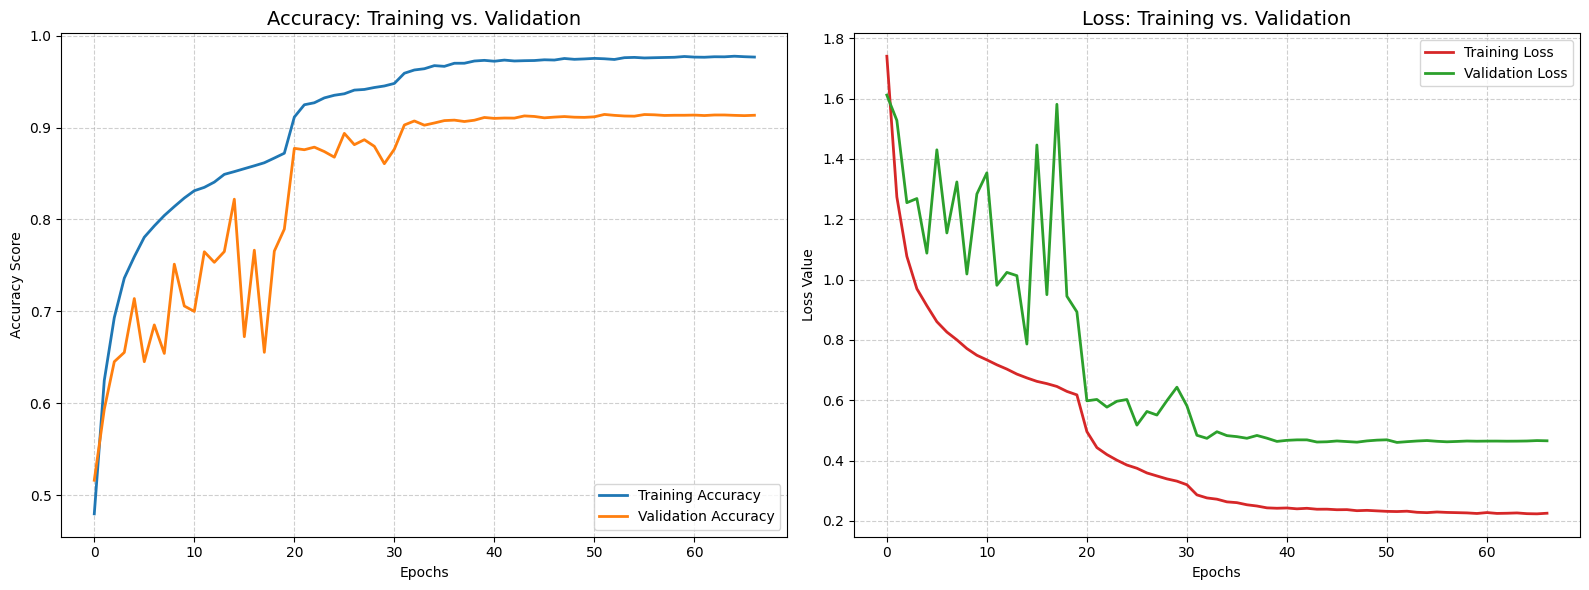

In [3]:
import matplotlib.pyplot as plt

def plot_training_results(history):
    # Extract data from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(16, 6))

    # 1. Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', linewidth=2)
    plt.title('Accuracy: Training vs. Validation', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy Score')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)

    # 2. Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='#d62728', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='#2ca02c', linewidth=2)
    plt.title('Loss: Training vs. Validation', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Call the function
plot_training_results(history)